# Digital Shadow of a Fuel System Testbed – Analysis & Fault Characterisation

**What this notebook does**
This notebook builds a *digital shadow* of a laboratory fuel system. It loads healthy and faulted datasets, cleans and merges them, and analyses system behaviour using pressure and flow measurements. The goal is to characterise how the system responds under different conditions and create a simple, interpretable pump model.

**Scope**
- Establish a healthy baseline (pressure and volumetric flow behaviour).
- Analyse fault scenarios (progressive restrictions / degradations) and their effect on signals.
- Quantify severity trends and percentage deviations from healthy operation.
- Compare observed pump behaviour to reference performance and fit a predictive model.

**Outputs you’ll see**
- Summary tables and trend plots for key pressures and flow.
- Fault response visualisations across severity levels.
- A fitted pump surface/model and basic accuracy metrics.


**Import Libaries

In [ ]:
#importing the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os
import glob

In [ ]:
#connecting goole colab to my drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**HEALTHY STATE 1**

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_1.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_1_df = pd.read_csv(file_path)

In [ ]:
healthy_data_1_df = healthy_data_1_df.drop(columns=["Comment", healthy_data_1_df.columns[5]])
healthy_data_1_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_1_df.iloc[:, 1:] = healthy_data_1_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_1_df["PreValve_Pressure"] = healthy_data_1_df["PreValve_Pressure"] + 1.013
healthy_data_1_df["PostValve_Pressure"] = healthy_data_1_df["PostValve_Pressure"] + 1.013
healthy_data_1_df["Final_Pressure"] = healthy_data_1_df["Final_Pressure"] + 1.013

In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_1_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.911039             0.869269           1.332480   
median            0.912000             0.870000           1.333000   
std               0.013530             0.015330           0.004461   
var               0.000183             0.000235           0.000020   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.232476              0.714922        1.128930  
median            1.233000              0.715000        1.129000  
std               0.002817              0.002771        0.006938  
var               0.000008              0.000008        0.000048  


HEALTHY DATA 2

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_2.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_2_df = pd.read_csv(file_path)

In [ ]:
healthy_data_2_df = healthy_data_2_df.drop(columns=["Comment", healthy_data_2_df.columns[5]])
healthy_data_2_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_2_df.iloc[:, 1:] = healthy_data_2_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_2_df["PreValve_Pressure"] = healthy_data_2_df["PreValve_Pressure"] + 1.013
healthy_data_2_df["PostValve_Pressure"] = healthy_data_2_df["PostValve_Pressure"] + 1.013
healthy_data_2_df["Final_Pressure"] = healthy_data_2_df["Final_Pressure"] + 1.013

In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_2_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.911318             0.867067           1.333563   
median            0.912000             0.868000           1.334000   
std               0.013209             0.014752           0.004340   
var               0.000174             0.000218           0.000019   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.233491              0.715606        1.129557  
median            1.234000              0.715000        1.130000  
std               0.002748              0.002817        0.006994  
var               0.000008              0.000008        0.000049  


HEALTHY DATA 3

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_3.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_3_df = pd.read_csv(file_path)

In [ ]:
healthy_data_3_df = healthy_data_3_df.drop(columns=["Comment", healthy_data_3_df.columns[5]])
healthy_data_3_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_3_df.iloc[:, 1:] = healthy_data_3_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_3_df["PreValve_Pressure"] = healthy_data_3_df["PreValve_Pressure"] + 1.013
healthy_data_3_df["PostValve_Pressure"] = healthy_data_3_df["PostValve_Pressure"] + 1.013
healthy_data_3_df["Final_Pressure"] = healthy_data_3_df["Final_Pressure"] + 1.013


In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_3_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.910521             0.866513           1.333385   
median            0.911000             0.867000           1.334000   
std               0.012939             0.014450           0.004319   
var               0.000167             0.000209           0.000019   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.233425              0.715926        1.129504  
median            1.234000              0.716000        1.130000  
std               0.002756              0.002779        0.006963  
var               0.000008              0.000008        0.000048  


HEALTHY DATA 4

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_4.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_4_df = pd.read_csv(file_path)

In [ ]:
healthy_data_4_df = healthy_data_4_df.drop(columns=["Comment", healthy_data_4_df.columns[5]])
healthy_data_4_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_4_df.iloc[:, 1:] = healthy_data_4_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_4_df["PreValve_Pressure"] = healthy_data_4_df["PreValve_Pressure"] + 1.013
healthy_data_4_df["PostValve_Pressure"] = healthy_data_4_df["PostValve_Pressure"] + 1.013
healthy_data_4_df["Final_Pressure"] = healthy_data_4_df["Final_Pressure"] + 1.013


In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_4_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.909703             0.866400           1.333182   
median            0.911000             0.867000           1.334000   
std               0.012801             0.014304           0.004346   
var               0.000164             0.000205           0.000019   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.233339              0.715832        1.129527  
median            1.234000              0.716000        1.130000  
std               0.002758              0.002858        0.007005  
var               0.000008              0.000008        0.000049  


HEALTHY DATA 5

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_5.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_5_df = pd.read_csv(file_path)

In [ ]:
healthy_data_5_df = healthy_data_5_df.drop(columns=["Comment", healthy_data_5_df.columns[5]])
healthy_data_5_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_5_df.iloc[:, 1:] = healthy_data_5_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_5_df["PreValve_Pressure"] = healthy_data_5_df["PreValve_Pressure"] + 1.013
healthy_data_5_df["PostValve_Pressure"] = healthy_data_5_df["PostValve_Pressure"] + 1.013
healthy_data_5_df["Final_Pressure"] = healthy_data_5_df["Final_Pressure"] + 1.013


In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_5_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.909164             0.866000           1.332786   
median            0.910000             0.867000           1.333000   
std               0.012668             0.014179           0.004334   
var               0.000160             0.000201           0.000019   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.233057              0.715995        1.129365  
median            1.233000              0.716000        1.130000  
std               0.002728              0.002839        0.006962  
var               0.000007              0.000008        0.000048  


HEALHTY DATA 6

In [ ]:
folder_path = '/content/drive/MyDrive/HEALTHY DATA'
file_name = 'Healthy_Data_6.csv'
file_path = os.path.join(folder_path, file_name)

# Read the CSV file into a pandas DataFrame
healthy_data_6_df = pd.read_csv(file_path)

In [ ]:
healthy_data_6_df = healthy_data_6_df.drop(columns=["Comment", healthy_data_6_df.columns[5]])
healthy_data_6_df.columns = ["Time", "PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure", "Pump_speed", "DPV1", "DPV2", "DPV3", "DPV4", "DPV5"]

In [ ]:
# Round all columns except 'Time' to 3 decimal places
healthy_data_6_df.iloc[:, 1:] = healthy_data_6_df.iloc[:, 1:].round(3)


In [ ]:
# Convert to absolute pressure
healthy_data_6_df["PreValve_Pressure"] = healthy_data_6_df["PreValve_Pressure"] + 1.013
healthy_data_6_df["PostValve_Pressure"] = healthy_data_6_df["PostValve_Pressure"] + 1.013
healthy_data_6_df["Final_Pressure"] = healthy_data_6_df["Final_Pressure"] + 1.013


In [ ]:
# Define the variables for which to calculate statistical measures
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure",
             "PostValve_Pressure", "volumetric_flow_rate", "Final_Pressure"]

# Calculate statistical measures
stats = healthy_data_6_df [variables].agg(['mean', 'median', 'std', 'var'])

# Display results
print(stats)


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean              0.908563             0.865723           1.332496   
median            0.909000             0.866000           1.333000   
std               0.012577             0.014093           0.004377   
var               0.000158             0.000199           0.000019   

        PostValve_Pressure  volumetric_flow_rate  Final_Pressure  
mean              1.232871              0.715819        1.129302  
median            1.233000              0.716000        1.130000  
std               0.002769              0.002798        0.007013  
var               0.000008              0.000008        0.000049  


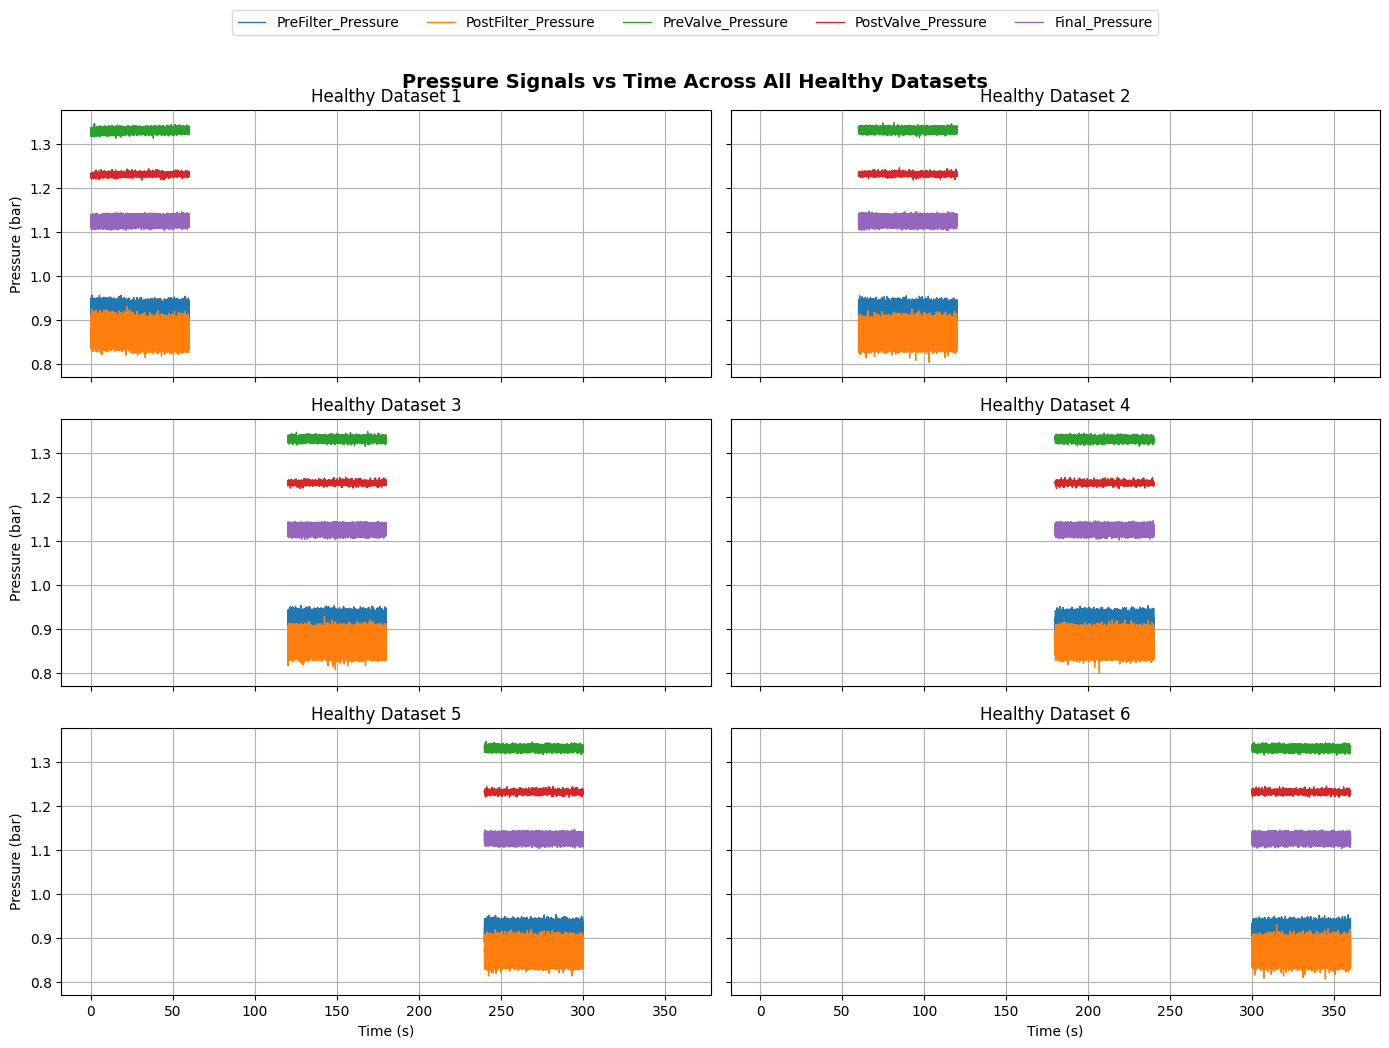

In [ ]:
# Put all dataframes in a list
healthy_dfs = [healthy_data_1_df, healthy_data_2_df, healthy_data_3_df, healthy_data_4_df, healthy_data_5_df, healthy_data_6_df]

# Define pressure columns
pressure_columns = [
    "PreFilter_Pressure", "PostFilter_Pressure",
    "PreValve_Pressure", "PostValve_Pressure", "Final_Pressure"
]

# Create 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Plot each dataset
for i, df in enumerate(healthy_dfs):
    ax = axes[i]
    for col in pressure_columns:
        ax.plot(df["Time"], df[col], label=col, linewidth=1)
    ax.set_title(f"Healthy Dataset {i+1}")
    ax.grid(True)
    if i >= 4:  # Label x-axis only on bottom row
        ax.set_xlabel("Time (s)")
    if i % 2 == 0:  # Label y-axis on left column
        ax.set_ylabel("Pressure (bar)")

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle("Pressure Signals vs Time Across All Healthy Datasets", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
combined_df = pd.concat([healthy_data_1_df, healthy_data_2_df, healthy_data_3_df, healthy_data_4_df, healthy_data_5_df, healthy_data_6_df]
, ignore_index=True)


In [ ]:
# List of target variables
variables = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "Final_Pressure", "volumetric_flow_rate"]

# Calculate statistics
summary_stats = combined_df[variables].agg(['mean', 'median', 'std'])

# Display the result
print(summary_stats.round(4))


        PreFilter_Pressure  PostFilter_Pressure  PreValve_Pressure  \
mean                0.9101               0.8668             1.3330   
median              0.9110               0.8670             1.3330   
std                 0.0130               0.0146             0.0044   

        PostValve_Pressure  Final_Pressure  volumetric_flow_rate  
mean                1.2331          1.1294                0.7157  
median              1.2330          1.1300                0.7160  
std                 0.0028          0.0070                0.0028  


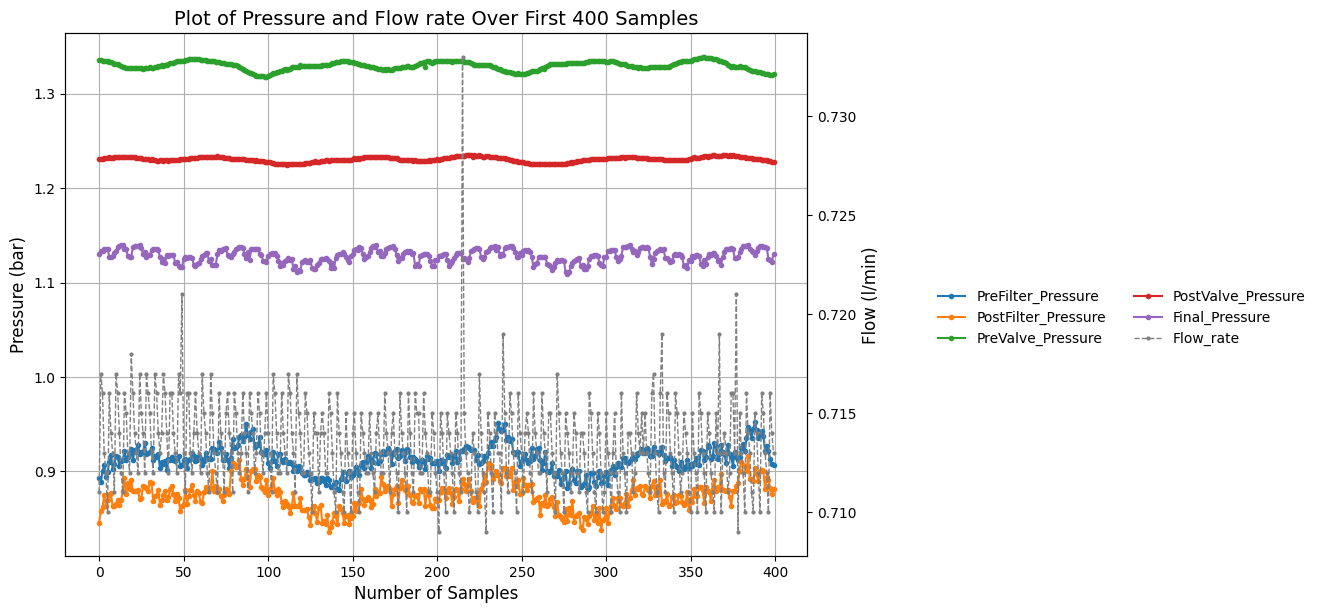

In [ ]:
# Select columns and sample range
pressure_columns = ["PreFilter_Pressure", "PostFilter_Pressure", "PreValve_Pressure", "PostValve_Pressure", "Final_Pressure"]
flow_column = "volumetric_flow_rate"

x_axis = combined_df.index[:400]
pressure_data = combined_df[pressure_columns].iloc[:400]
flow_data = combined_df[flow_column].iloc[:400]

# Plotting with scatter
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot pressure signals as scatter
for col in pressure_columns:
    ax1.plot(x_axis, pressure_data[col], label=col, marker='o', markersize=3, linestyle='-')  # Line plots with markers

ax1.set_xlabel("Number of Samples", fontsize=12)
ax1.set_ylabel("Pressure (bar)", fontsize=12)
ax1.grid(True)

# Flow plotted on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x_axis, flow_data, color='grey', label='Flow_rate', marker='o', markersize=2, linestyle='--', linewidth=1)

ax2.set_ylabel("Flow (l/min)", fontsize=12)

# Legend closer to plot (center right, slightly offset)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

fig.legend(
    handles=lines_1 + lines_2,
    labels=labels_1 + labels_2,
    loc='center left',
    bbox_to_anchor=(0.93, 0.5),
    frameon=False,
    ncol=2
)

# Adjust layout for legend spacing
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.title("Plot of Pressure and Flow rate Over First 400 Samples", fontsize=14,)
plt.show()


In [ ]:
combined_df_mean= combined_df.select_dtypes(include=np.number).mean()
combined_df_mean

,0
Time,179.999500
PreFilter_Pressure,0.910051
PostFilter_Pressure,0.866829
PreValve_Pressure,1.332982
PostValve_Pressure,1.233110
volumetric_flow_rate,0.715683
Final_Pressure,1.129364
Pump_speed,399.981139
DPV1,100.000000
DPV2,0.000000


CLOGGED FILTER

In [ ]:
cf1=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_1.csv')
cf2=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_2.csv')
cf3=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_3.csv')
cf4=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_4.csv')
cf5=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_5.csv')
cf6=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_6.csv')
cf7=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_7.csv')
cf8=pd.read_csv('/content/drive/MyDrive/Clogged Filter/Clogged_Filter_8.csv')

In [ ]:
new_column_names = ['Time', 'PreFilter_Pressure', 'PostFilter_Pressure', 'PreValve_Pressure', 'PostValve_Pressure','Flow0',
                    'volumetric_flow_rate', 'Final_Pressure', 'Pump_speed', 'DPV1', 'DPV2',
                    'DPV3', 'DPV4', 'DPV5', 'c']

In [ ]:
# Store all DataFrames in a list
clogged_files = [cf1, cf2, cf3, cf4, cf5, cf6, cf7, cf8]

for df in clogged_files:
    df.columns = new_column_names  # Assign the new column names
    df.drop(['Flow0','c'], axis=1, inplace=True) # Drop the 'F1' column


In [ ]:
# Columns to convert from gauge to absolute pressure
pressure_columns = ['PreValve_Pressure', 'PostValve_Pressure', 'Final_Pressure']

# Loop through each DataFrame and apply conversion
for i in range(len(clogged_files)):
    df = clogged_files[i]
    for col in pressure_columns:
        df[col] = df[col] + 1.013
    clogged_files[i] = df  # Update the list


In [ ]:
mean_cf1 = cf1.mean()
mean_cf2 = cf2.mean()
mean_cf3 = cf3.mean()
mean_cf4 = cf4.mean()
mean_cf5 = cf5.mean()
mean_cf6 = cf6.mean()
mean_cf7 = cf7.mean()
mean_cf8 = cf8.mean()

In [ ]:
# Assuming you have already calculated mean_clf1, mean_clf2, ..., mean_clf8
mean_values = [mean_cf1, mean_cf2, mean_cf3, mean_cf4,
               mean_cf5, mean_cf6, mean_cf7, mean_cf8]

# Create a dictionary to store the means, excluding 'Time' if it's present
data = {}
for i, values in enumerate(mean_values):
    data[f'cf{i+1}'] = values.drop('Time', errors='ignore')  # Ignore if 'Time' is not present

# Create a pandas DataFrame from the dictionary
df_means_cf = pd.DataFrame(data)

# Transpose the DataFrame to have columns as rows and vice-versa
df_means_cf = df_means_cf.T

# Reset the index to make 'clf1', 'clf2', etc. a column
df_means_cf = df_means_cf.reset_index()

# Display the combined DataFrame
df_means_cf

,index,PreFilter_Pressure,PostFilter_Pressure,PreValve_Pressure,PostValve_Pressure,volumetric_flow_rate,Final_Pressure,Pump_speed,DPV1,DPV2,DPV3,DPV4,DPV5
0,cf1,0.927166,0.348572,1.204479,1.143264,0.567797,1.071970,399.977752,20.0,0.0,100.0,0.0,100.0
1,cf2,0.924856,0.488062,1.235920,1.165298,0.608154,1.086331,399.989903,30.0,0.0,100.0,0.0,100.0
2,cf3,0.922563,0.629315,1.269771,1.189048,0.648100,1.101980,399.932865,40.0,0.0,100.0,0.0,100.0
3,cf4,0.910922,0.722605,1.291941,1.203659,0.675277,1.110185,399.962827,50.0,0.0,100.0,0.0,100.0
4,cf5,0.911518,0.791731,1.310340,1.216859,0.694890,1.118930,400.010487,60.0,0.0,100.0,0.0,100.0
5,cf6,0.912597,0.831879,1.321288,1.224875,0.705463,1.124469,400.008516,70.0,0.0,100.0,0.0,100.0
6,cf7,0.905208,0.845094,1.326097,1.228238,0.710814,1.126201,400.041191,80.0,0.0,100.0,0.0,100.0
7,cf8,0.908142,0.858261,1.330411,1.231412,0.714246,1.128319,399.997680,90.0,0.0,100.0,0.0,100.0


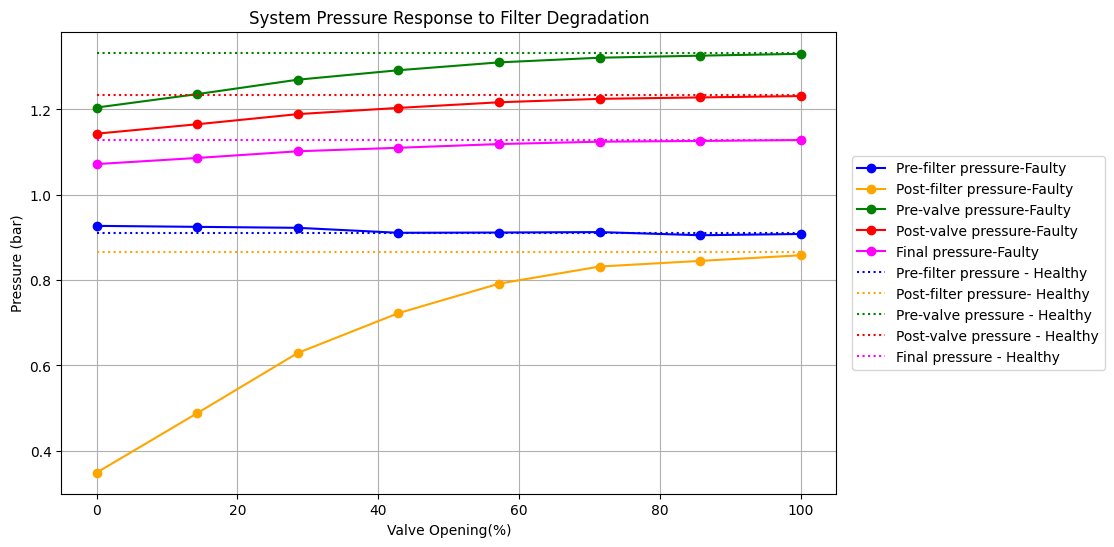

In [ ]:
# Pressure values for clogged filters
P1_clogged = df_means_cf['PreFilter_Pressure']
P2_clogged = df_means_cf['PostFilter_Pressure']
P3_clogged = df_means_cf['PreValve_Pressure']
P4_clogged = df_means_cf['PostValve_Pressure']
P5_clogged = df_means_cf['Final_Pressure']

# Healthy pressures
# Use the length of P1_clogged (or any other clogged pressure) to determine degradation steps
degradation_steps = len(P1_clogged)  # 8 in this case
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Adjust the length of healthy pressures to match degradation
P1_healthy = [combined_df_mean['PreFilter_Pressure']] * degradation_steps
P2_healthy = [combined_df_mean['PostFilter_Pressure']] * degradation_steps
P3_healthy = [combined_df_mean['PreValve_Pressure']] * degradation_steps
P4_healthy = [combined_df_mean['PostValve_Pressure']] * degradation_steps
P5_healthy = [combined_df_mean['Final_Pressure']] * degradation_steps

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(degradation, P1_clogged, 'o-', label="Pre-filter pressure-Faulty", color='blue')
plt.plot(degradation, P2_clogged, 'o-', label="Post-filter pressure-Faulty", color='orange')
plt.plot(degradation, P3_clogged, 'o-', label="Pre-valve pressure-Faulty", color='green')
plt.plot(degradation, P4_clogged, 'o-', label="Post-valve pressure-Faulty", color='red')
plt.plot(degradation, P5_clogged, 'o-', label="Final pressure-Faulty", color='magenta')

# Dotted lines for healthy reference
plt.plot(degradation, P1_healthy, 'blue', linestyle='dotted', label="Pre-filter pressure - Healthy")
plt.plot(degradation, P2_healthy, 'orange', linestyle='dotted', label="Post-filter pressure- Healthy")
plt.plot(degradation, P3_healthy, 'green', linestyle='dotted', label="Pre-valve pressure - Healthy")
plt.plot(degradation, P4_healthy, 'red', linestyle='dotted', label="Post-valve pressure - Healthy")
plt.plot(degradation, P5_healthy, 'magenta', linestyle='dotted', label="Final pressure - Healthy")

plt.xlabel("Valve Opening(%)")
plt.ylabel("Pressure (bar)")
plt.title("System Pressure Response to Filter Degradation")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True)
plt.show()

In [ ]:
combined_cf_df = pd.concat([cf1, cf2, cf3, cf4, cf5, cf6, cf7, cf8]
, ignore_index=True)


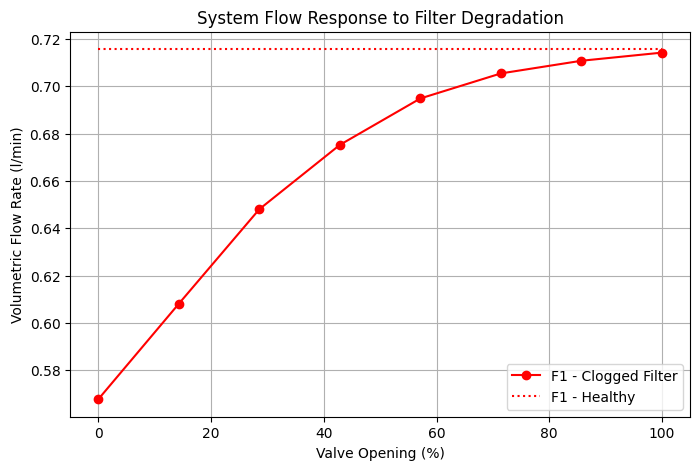

In [ ]:
# Example: Plot for PreFilter Pressure only

# Clogged filter pressure data
flow_clogged = df_means_cf['volumetric_flow_rate']

# Healthy reference line (repeated to match degradation steps)
flow_healthy = [combined_df_mean['volumetric_flow_rate']] * len(flow_clogged)

# Degradation axis (0% to 100%)
degradation_steps = len(flow_clogged)
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]


# Plotting
plt.figure(figsize=(8, 5))
plt.plot(degradation, flow_clogged, 'o-', color='red', label="F1 - Clogged Filter")
plt.plot(degradation, flow_healthy, linestyle='dotted', color='red', label="F1 - Healthy")

plt.xlabel("Valve Opening (%)")
plt.ylabel("Volumetric Flow Rate (l/min)")
plt.title("System Flow Response to Filter Degradation")
plt.legend()
plt.grid(True)
plt.show()


DEGRADED PUMP

In [ ]:
df_list = [
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_1.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_2.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_3.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_4.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_5.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_6.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_7.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_8.csv'),
  pd.read_csv('/content/drive/MyDrive/F2- Degraded Pump/Degrarded_Pump_9.csv'),
]

In [ ]:
dp9 = df_list[0]
dp8 = df_list[1]
dp7 = df_list[2]
dp6 = df_list[3]
dp5 = df_list[4]
dp4 = df_list[5]
dp3 = df_list[6]
dp2 = df_list[7]
dp1 = df_list[8]

In [ ]:
# Store all DataFrames in a list
degraded_files = [dp1, dp2, dp3, dp4, dp5, dp6, dp7, dp8, dp9]

for df in degraded_files:
    df.columns = new_column_names  # Assign the new column names
    df.drop(['Flow0','c'], axis=1, inplace=True) # Drop the 'F1' column


In [ ]:
# Columns to convert from gauge to absolute pressure
pressure_columns = ['PreValve_Pressure', 'PostValve_Pressure', 'Final_Pressure']

# Loop through each DataFrame and apply conversion
for i in range(len(degraded_files)):
    df = degraded_files[i]
    for col in pressure_columns:
        df[col] = df[col] + 1.013
    degraded_files[i] = df  # Update the list


In [ ]:
mean_dp1 = dp1.mean()
mean_dp2 = dp2.mean()
mean_dp3 = dp3.mean()
mean_dp4 = dp4.mean()
mean_dp5 = dp5.mean()
mean_dp6 = dp6.mean()
mean_dp7 = dp7.mean()
mean_dp8 = dp8.mean()
mean_dp9 = dp9.mean()

In [ ]:
# Assuming you have already calculated mean_clf1, mean_clf2, ..., mean_clf8
mean_values = [mean_dp1, mean_dp2, mean_dp3, mean_dp4,
               mean_dp5, mean_dp6, mean_dp7, mean_dp8, mean_dp9]

# Create a dictionary to store the means, excluding 'Time' if it's present
data = {}
for i, values in enumerate(mean_values):
    data[f'dp{i+1}'] = values.drop('Time', errors='ignore')  # Ignore if 'Time' is not present

# Create a pandas DataFrame from the dictionary
df_means_dp = pd.DataFrame(data)

# Transpose the DataFrame to have columns as rows and vice-versa
df_means_dp = df_means_dp.T

# Reset the index to make 'clf1', 'clf2', etc. a column
df_means_cf = df_means_dp.reset_index()

# Display the combined DataFrame
df_means_dp

,PreFilter_Pressure,PostFilter_Pressure,PreValve_Pressure,PostValve_Pressure,volumetric_flow_rate,Final_Pressure,Pump_speed,DPV1,DPV2,DPV3,DPV4,DPV5
dp1,0.911577,0.863977,1.323396,1.225467,0.710711,1.124828,400.051033,100.0,20.0,100.0,0.0,100.0
dp2,0.900980,0.851172,1.250997,1.174392,0.634920,1.090892,400.006876,100.0,30.0,100.0,0.0,100.0
dp3,0.890699,0.836559,1.168461,1.116482,0.534823,1.052806,400.083630,100.0,40.0,100.0,0.0,100.0
dp4,0.892395,0.839269,1.105656,1.071315,0.453545,1.023693,399.952462,100.0,50.0,100.0,0.0,100.0
dp5,0.885670,0.830442,1.078006,1.052816,0.403520,1.013092,400.024448,100.0,60.0,100.0,0.0,100.0
dp6,0.880390,0.823333,1.063778,1.042748,0.374854,1.013088,400.017729,100.0,70.0,100.0,0.0,100.0
dp7,0.887578,0.830012,1.057544,1.038233,0.360942,1.013089,399.997008,100.0,80.0,100.0,0.0,100.0
dp8,0.883444,0.825517,1.054284,1.036053,0.351643,1.013087,400.090811,100.0,90.0,100.0,0.0,100.0
dp9,0.879591,0.821638,1.052259,1.034520,0.346820,1.013091,400.037835,100.0,100.0,100.0,0.0,100.0


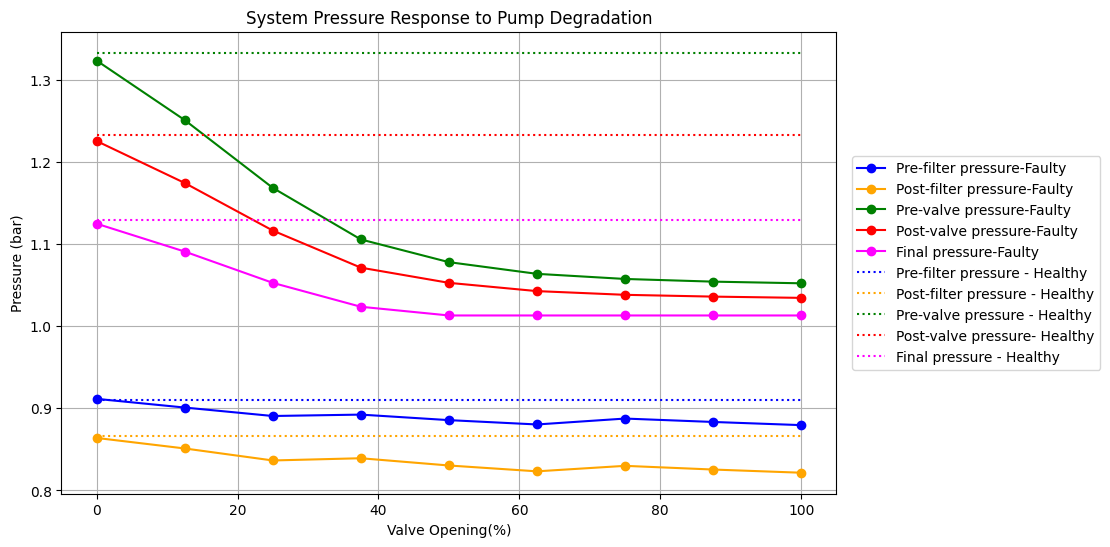

In [ ]:
# Pressure values for clogged filters
P1_degraded = df_means_dp['PreFilter_Pressure']
P2_degraded = df_means_dp['PostFilter_Pressure']
P3_degraded = df_means_dp['PreValve_Pressure']
P4_degraded = df_means_dp['PostValve_Pressure']
P5_degraded = df_means_dp['Final_Pressure']

# Healthy pressures
# Use the length of P1_clogged (or any other clogged pressure) to determine degradation steps
degradation_steps = len(P1_degraded)  # 8 in this case
degradation = [(100 / (degradation_steps- 1)) * i for i in range(degradation_steps)]

# Adjust the length of healthy pressures to match degradation
P1_healthy = [combined_df_mean['PreFilter_Pressure']] * degradation_steps
P2_healthy = [combined_df_mean['PostFilter_Pressure']] * degradation_steps
P3_healthy = [combined_df_mean['PreValve_Pressure']] * degradation_steps
P4_healthy = [combined_df_mean['PostValve_Pressure']] * degradation_steps
P5_healthy = [combined_df_mean['Final_Pressure']] * degradation_steps

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(degradation, P1_degraded, 'o-', label="Pre-filter pressure-Faulty", color='blue')
plt.plot(degradation, P2_degraded, 'o-', label="Post-filter pressure-Faulty", color='orange')
plt.plot(degradation, P3_degraded, 'o-', label="Pre-valve pressure-Faulty", color='green')
plt.plot(degradation, P4_degraded, 'o-', label="Post-valve pressure-Faulty", color='red')
plt.plot(degradation, P5_degraded, 'o-', label="Final pressure-Faulty", color='magenta')

# Dotted lines for healthy reference
plt.plot(degradation, P1_healthy, 'blue', linestyle='dotted', label="Pre-filter pressure - Healthy")
plt.plot(degradation, P2_healthy, 'orange', linestyle='dotted', label="Post-filter pressure - Healthy")
plt.plot(degradation, P3_healthy, 'green', linestyle='dotted', label="Pre-valve pressure - Healthy")
plt.plot(degradation, P4_healthy, 'red', linestyle='dotted', label="Post-valve pressure- Healthy")
plt.plot(degradation, P5_healthy, 'magenta', linestyle='dotted', label="Final pressure - Healthy")

plt.xlabel("Valve Opening(%)")
plt.ylabel("Pressure (bar)")
plt.title("System Pressure Response to Pump Degradation")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True)
plt.show()

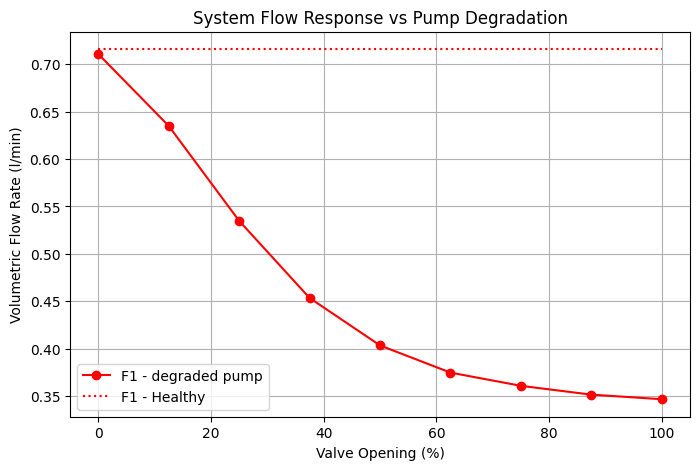

In [ ]:
# Example: Plot for PreFilter Pressure only

# Clogged filter pressure data
flow_degraded = df_means_dp['volumetric_flow_rate']

# Healthy reference line (repeated to match degradation steps)
flow_healthy = [combined_df_mean['volumetric_flow_rate']] * len(flow_degraded)

# Degradation axis (0% to 100%)
degradation_steps = len(flow_degraded)
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(degradation, flow_degraded, 'o-', color='red', label="F1 - degraded pump")
plt.plot(degradation, flow_healthy, linestyle='dotted', color='red', label="F1 - Healthy")

plt.xlabel("Valve Opening (%)")
plt.ylabel("Volumetric Flow Rate (l/min)")
plt.title("System Flow Response vs Pump Degradation")
plt.legend()
plt.grid(True)
plt.show()


STUCK VALVE

In [ ]:
df_list = [
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_1.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_2.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_3.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_4.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_5.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_6.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_7.csv'),
  pd.read_csv('/content/drive/MyDrive/F3-Stuck Valve/Stuck_valve_8.csv'),
]

In [ ]:
sv1=df_list[0]
sv2=df_list[1]
sv3=df_list[2]
sv4=df_list[3]
sv5=df_list[4]
sv6=df_list[5]
sv7=df_list[6]
sv8=df_list[7]

In [ ]:
# Store all DataFrames in a list
stuck_files = [sv1, sv2, sv3, sv4, sv5, sv6, sv7, sv8]

for df in stuck_files:
    df.columns = new_column_names  # Assign the new column names
    df.drop(['Flow0','c'], axis=1, inplace=True) # Drop the 'F1' column


In [ ]:
# Columns to convert from gauge to absolute pressure
pressure_columns = ['PreValve_Pressure', 'PostValve_Pressure', 'Final_Pressure']

# Loop through each DataFrame and apply conversion
for i in range(len(stuck_files)):
    df = stuck_files[i]
    for col in pressure_columns:
        df[col] = df[col] + 1.013
    stuck_files[i] = df  # Update the list


In [ ]:
mean_sv1 = sv1.mean()
mean_sv2 = sv2.mean()
mean_sv3 = sv3.mean()
mean_sv4 = sv4.mean()
mean_sv5 = sv5.mean()
mean_sv6 = sv6.mean()
mean_sv7 = sv7.mean()
mean_sv8 = sv8.mean()

In [ ]:
# Assuming you have already calculated mean_clf1, mean_clf2, ..., mean_clf8
mean_values = [mean_sv1, mean_sv2, mean_sv3, mean_sv4,
               mean_sv5, mean_sv6, mean_sv7, mean_sv8]

# Create a dictionary to store the means, excluding 'Time' if it's present
data = {}
for i, values in enumerate(mean_values):
    data[f'sv{i+1}'] = values.drop('Time', errors='ignore')  # Ignore if 'Time' is not present

# Create a pandas DataFrame from the dictionary
df_means_sv = pd.DataFrame(data)

# Transpose the DataFrame to have columns as rows and vice-versa
df_means_sv = df_means_sv.T

# Reset the index to make 'clf1', 'clf2', etc. a column
df_means_sv = df_means_sv.reset_index()

# Display the combined DataFrame
df_means_sv

,index,PreFilter_Pressure,PostFilter_Pressure,PreValve_Pressure,PostValve_Pressure,volumetric_flow_rate,Final_Pressure,Pump_speed,DPV1,DPV2,DPV3,DPV4,DPV5
0,sv1,0.923445,0.897066,1.765760,1.126303,0.556682,1.058653,399.993924,100.0,0.0,20.0,0.0,100.0
1,sv2,0.919059,0.888518,1.639378,1.150149,0.598093,1.074030,399.973931,100.0,0.0,30.0,0.0,100.0
2,sv3,0.915563,0.880910,1.526477,1.173335,0.636555,1.089460,400.048119,100.0,0.0,40.0,0.0,100.0
3,sv4,0.912542,0.874680,1.441102,1.192282,0.665762,1.102032,400.195861,100.0,0.0,50.0,0.0,100.0
4,sv5,0.910670,0.869977,1.381985,1.205437,0.687460,1.111096,399.971494,100.0,0.0,60.0,0.0,100.0
5,sv6,0.910409,0.868655,1.349890,1.213663,0.699593,1.116535,400.047621,100.0,0.0,70.0,0.0,100.0
6,sv7,0.910982,0.867968,1.332304,1.218390,0.706355,1.119723,399.993807,100.0,0.0,80.0,0.0,100.0
7,sv8,0.912400,0.869048,1.323061,1.221010,0.708657,1.121510,399.997235,100.0,0.0,90.0,0.0,100.0


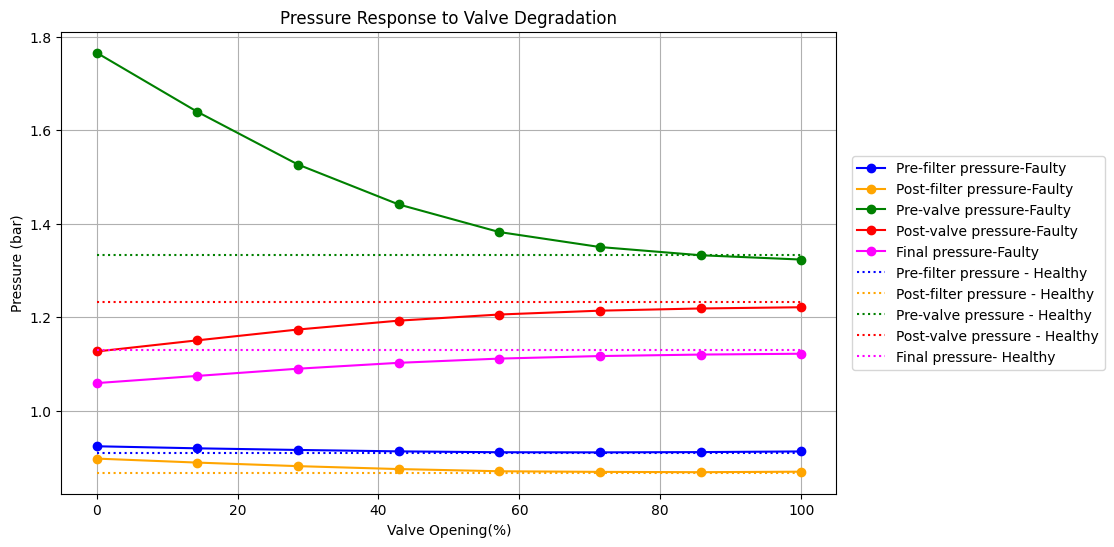

In [ ]:
# Pressure values for clogged filters
P1_stuck = df_means_sv['PreFilter_Pressure']
P2_stuck = df_means_sv['PostFilter_Pressure']
P3_stuck = df_means_sv['PreValve_Pressure']
P4_stuck = df_means_sv['PostValve_Pressure']
P5_stuck = df_means_sv['Final_Pressure']

# Healthy pressures
# Use the length of P1_clogged (or any other clogged pressure) to determine degradation steps
degradation_steps = len(P1_stuck)  # 8 in this case
degradation = [(100 / (degradation_steps- 1)) * i for i in range(degradation_steps)]

# Adjust the length of healthy pressures to match degradation
P1_healthy = [combined_df_mean['PreFilter_Pressure']] * degradation_steps
P2_healthy = [combined_df_mean['PostFilter_Pressure']] * degradation_steps
P3_healthy = [combined_df_mean['PreValve_Pressure']] * degradation_steps
P4_healthy = [combined_df_mean['PostValve_Pressure']] * degradation_steps
P5_healthy = [combined_df_mean['Final_Pressure']] * degradation_steps

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(degradation, P1_stuck, 'o-', label="Pre-filter pressure-Faulty", color='blue')
plt.plot(degradation, P2_stuck, 'o-', label="Post-filter pressure-Faulty", color='orange')
plt.plot(degradation, P3_stuck, 'o-', label="Pre-valve pressure-Faulty", color='green')
plt.plot(degradation, P4_stuck, 'o-', label="Post-valve pressure-Faulty", color='red')
plt.plot(degradation, P5_stuck, 'o-', label="Final pressure-Faulty", color='magenta')

# Dotted lines for healthy reference
plt.plot(degradation, P1_healthy, 'blue', linestyle='dotted', label="Pre-filter pressure - Healthy")
plt.plot(degradation, P2_healthy, 'orange', linestyle='dotted', label="Post-filter pressure - Healthy")
plt.plot(degradation, P3_healthy, 'green', linestyle='dotted', label="Pre-valve pressure - Healthy")
plt.plot(degradation, P4_healthy, 'red', linestyle='dotted', label="Post-valve pressure - Healthy")
plt.plot(degradation, P5_healthy, 'magenta', linestyle='dotted', label="Final pressure- Healthy")

plt.xlabel("Valve Opening(%)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Response to Valve Degradation")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True)
plt.show()

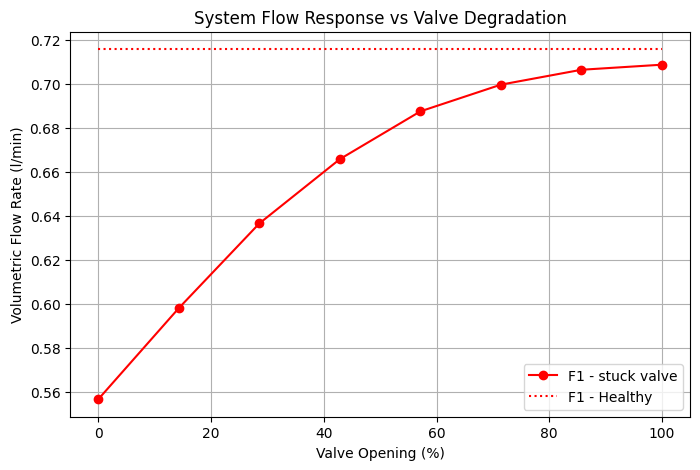

In [ ]:
# Example: Plot for PreFilter Pressure only

# Clogged filter pressure data
flow_stuck = df_means_sv['volumetric_flow_rate']

# Healthy reference line (repeated to match degradation steps)
flow_healthy = [combined_df_mean['volumetric_flow_rate']] * len(flow_stuck)

# Degradation axis (0% to 100%)
degradation_steps = len(flow_stuck)
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(degradation, flow_stuck, 'o-', color='red', label="F1 - stuck valve")
plt.plot(degradation, flow_healthy, linestyle='dotted', color='red', label="F1 - Healthy")

plt.xlabel("Valve Opening (%)")
plt.ylabel("Volumetric Flow Rate (l/min)")
plt.title("System Flow Response vs Valve Degradation")
plt.legend()
plt.grid(True)
plt.show()


LEAKING PIPE

In [ ]:
df_list = [
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_1.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_2.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_3.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_4.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_5.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_6.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_7.csv'),
  pd.read_csv('/content/drive/MyDrive/F4-Leaking Pipe/Leaking_Pipe_8.csv'),
]

In [ ]:
lp8=df_list[0]
lp7=df_list[1]
lp6=df_list[2]
lp5=df_list[3]
lp4=df_list[4]
lp3=df_list[5]
lp2=df_list[6]
lp1=df_list[7]

In [ ]:
# Store all DataFrames in a list
leak= [lp1, lp2, lp3, lp4, lp5, lp6, lp7, lp8]

for df in leak:
    df.columns = new_column_names  # Assign the new column names
    df.drop(['Flow0','c'], axis=1, inplace=True) # Drop the 'F1' column

In [ ]:
# Columns to convert from gauge to absolute pressure
pressure_columns = ['PreValve_Pressure', 'PostValve_Pressure', 'Final_Pressure']

# Loop through each DataFrame and apply conversion
for i in range(len(leak)):
    df = leak[i]
    for col in pressure_columns:
        df[col] = df[col] + 1.013
    leak[i] = df  # Update the list


In [ ]:
mean_lp1 = lp1.mean()
mean_lp2 = lp2.mean()
mean_lp3 = lp3.mean()
mean_lp4 = lp4.mean()
mean_lp5 = lp5.mean()
mean_lp6 = lp6.mean()
mean_lp7 = lp7.mean()
mean_lp8 = lp8.mean()

In [ ]:
# Assuming you have already calculated mean_clf1, mean_clf2, ..., mean_clf8
mean_values = [mean_lp1, mean_lp2, mean_lp3, mean_lp4,
               mean_lp5, mean_lp6, mean_lp7, mean_lp8]

# Create a dictionary to store the means, excluding 'Time' if it's present
data = {}
for i, values in enumerate(mean_values):
    data[f'lp{i+1}'] = values.drop('Time', errors='ignore')  # Ignore if 'Time' is not present

# Create a pandas DataFrame from the dictionary
df_means_lp = pd.DataFrame(data)

# Transpose the DataFrame to have columns as rows and vice-versa
df_means_lp= df_means_lp.T

# Reset the index to make 'clf1', 'clf2', etc. a column
df_means_lp = df_means_lp.reset_index()

# Display the combined DataFrame
df_means_lp

,index,PreFilter_Pressure,PostFilter_Pressure,PreValve_Pressure,PostValve_Pressure,volumetric_flow_rate,Final_Pressure,Pump_speed,DPV1,DPV2,DPV3,DPV4,DPV5
0,lp1,0.912394,0.869145,1.313193,1.218749,0.691526,1.119772,399.999661,100.0,0.0,100.0,20.0,100.0
1,lp2,0.909828,0.866431,1.313291,1.218752,0.696628,1.119610,400.019576,100.0,0.0,100.0,30.0,100.0
2,lp3,0.903056,0.855992,1.242758,1.141500,0.566975,1.065294,399.936870,100.0,0.0,100.0,40.0,100.0
3,lp4,0.898320,0.849397,1.202331,1.097185,0.478163,1.034554,400.043087,100.0,0.0,100.0,50.0,100.0
4,lp5,0.895353,0.845374,1.184501,1.076982,0.432510,1.021029,400.025728,100.0,0.0,100.0,60.0,100.0
5,lp6,0.892766,0.842801,1.176431,1.068237,0.410835,1.015215,400.000533,100.0,0.0,100.0,70.0,100.0
6,lp7,0.902602,0.852352,1.171667,1.063331,0.353455,1.013114,399.973331,100.0,0.0,100.0,80.0,100.0
7,lp8,0.900618,0.849934,1.169494,1.061101,0.346331,1.013112,400.088143,100.0,0.0,100.0,90.0,100.0


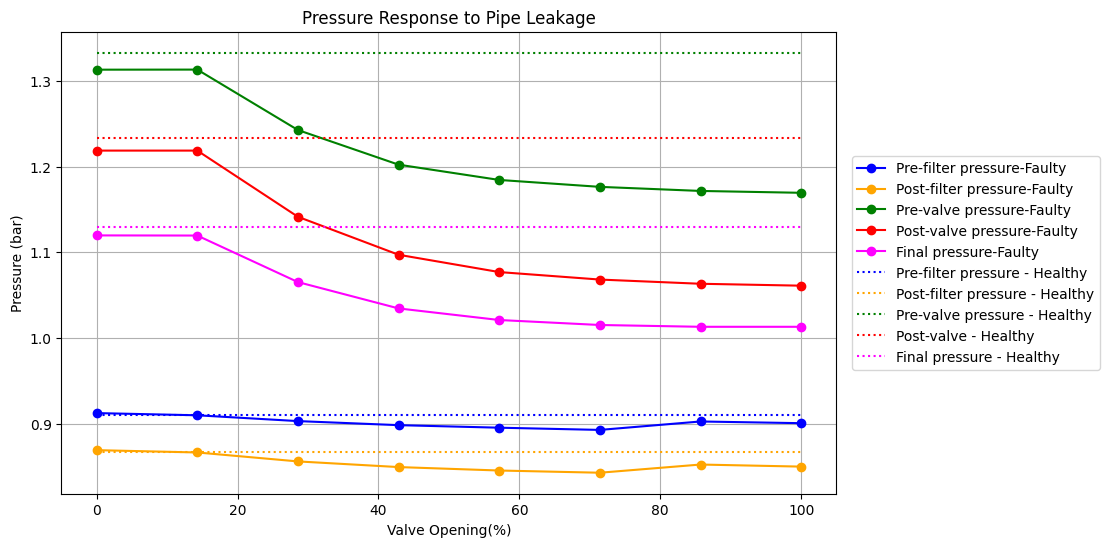

In [ ]:
# Pressure values for clogged filters
P1_leak = df_means_lp['PreFilter_Pressure']
P2_leak = df_means_lp['PostFilter_Pressure']
P3_leak = df_means_lp['PreValve_Pressure']
P4_leak = df_means_lp['PostValve_Pressure']
P5_leak = df_means_lp['Final_Pressure']

# Healthy pressures
# Use the length of P1_clogged (or any other clogged pressure) to determine degradation steps
degradation_steps = len(P1_leak)  # 8 in this case
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Adjust the length of healthy pressures to match degradation
P1_healthy = [combined_df_mean['PreFilter_Pressure']] * degradation_steps
P2_healthy = [combined_df_mean['PostFilter_Pressure']] * degradation_steps
P3_healthy = [combined_df_mean['PreValve_Pressure']] * degradation_steps
P4_healthy = [combined_df_mean['PostValve_Pressure']] * degradation_steps
P5_healthy = [combined_df_mean['Final_Pressure']] * degradation_steps

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(degradation, P1_leak, 'o-', label="Pre-filter pressure-Faulty", color='blue')
plt.plot(degradation, P2_leak, 'o-', label="Post-filter pressure-Faulty", color='orange')
plt.plot(degradation, P3_leak, 'o-', label="Pre-valve pressure-Faulty", color='green')
plt.plot(degradation, P4_leak, 'o-', label="Post-valve pressure-Faulty", color='red')
plt.plot(degradation, P5_leak, 'o-', label="Final pressure-Faulty", color='magenta')

# Dotted lines for healthy reference
plt.plot(degradation, P1_healthy, 'blue', linestyle='dotted', label="Pre-filter pressure - Healthy")
plt.plot(degradation, P2_healthy, 'orange', linestyle='dotted', label="Post-filter pressure - Healthy")
plt.plot(degradation, P3_healthy, 'green', linestyle='dotted', label="Pre-valve pressure - Healthy")
plt.plot(degradation, P4_healthy, 'red', linestyle='dotted', label="Post-valve - Healthy")
plt.plot(degradation, P5_healthy, 'magenta', linestyle='dotted', label="Final pressure - Healthy")

plt.xlabel("Valve Opening(%)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Response to Pipe Leakage")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True)
plt.show()

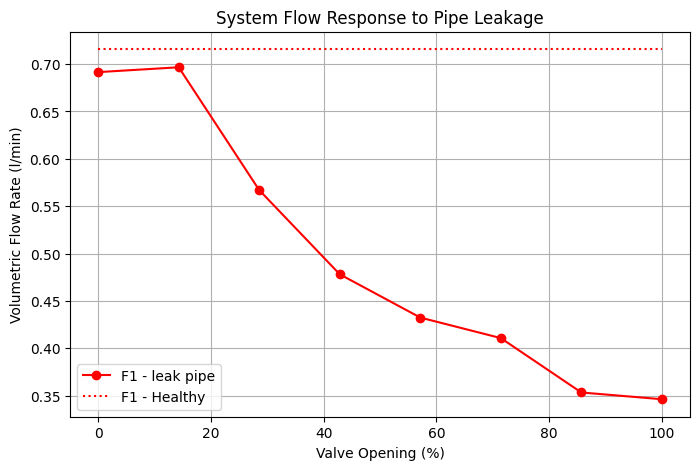

In [ ]:
# Example: Plot for PreFilter Pressure only

# Clogged filter pressure data
flow_leak = df_means_lp['volumetric_flow_rate']

# Healthy reference line (repeated to match degradation steps)
flow_healthy = [combined_df_mean['volumetric_flow_rate']] * len(flow_leak)

# Degradation axis (0% to 100%)
degradation_steps = len(flow_leak)
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(degradation, flow_leak, 'o-', color='red', label="F1 - leak pipe")
plt.plot(degradation, flow_healthy, linestyle='dotted', color='red', label="F1 - Healthy")

plt.xlabel("Valve Opening (%)")
plt.ylabel("Volumetric Flow Rate (l/min)")
plt.title("System Flow Response to Pipe Leakage")
plt.legend()
plt.grid(True)
plt.show()


CLOGGED NOZZLE

In [ ]:
df_list = [
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_1.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_2.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_3.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_4.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_5.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_6.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_7.csv'),
  pd.read_csv('/content/drive/MyDrive/F5- Clogged Injector/Clogged_injector_8.csv'),
]

In [ ]:
cn1=df_list[0]
cn2=df_list[1]
cn3=df_list[2]
cn4=df_list[3]
cn5=df_list[4]
cn6=df_list[5]
cn7=df_list[6]
cn8=df_list[7]

In [ ]:
# Store all DataFrames in a list
nozzle= [cn1, cn2, cn3, cn4, cn5, cn6, cn7, cn8]

for df in nozzle:
    df.columns = new_column_names  # Assign the new column names
    df.drop(['Flow0','c'], axis=1, inplace=True) # Drop the 'F1' column


In [ ]:
# Columns to convert from gauge to absolute pressure
pressure_columns = ['PreValve_Pressure', 'PostValve_Pressure', 'Final_Pressure']

# Loop through each DataFrame and apply conversion
for i in range(len(nozzle)):
    df = nozzle[i]
    for col in pressure_columns:
        df[col] = df[col] + 1.013
    nozzle[i] = df  # Update the list


In [ ]:
mean_cn1 = cn1.mean()
mean_cn2 = cn2.mean()
mean_cn3 = cn3.mean()
mean_cn4 = cn4.mean()
mean_cn5 = cn5.mean()
mean_cn6 = cn6.mean()
mean_cn7 = cn7.mean()
mean_cn8 = cn8.mean()

In [ ]:
# Assuming you have already calculated mean_clf1, mean_clf2, ..., mean_clf8
mean_values = [mean_cn1, mean_cn2, mean_cn3, mean_cn4,
               mean_cn5, mean_cn6, mean_cn7, mean_cn8]

# Create a dictionary to store the means, excluding 'Time' if it's present
data = {}
for i, values in enumerate(mean_values):
    data[f'cn{i+1}'] = values.drop('Time', errors='ignore')  # Ignore if 'Time' is not present

# Create a pandas DataFrame from the dictionary
df_means_cn = pd.DataFrame(data)

# Transpose the DataFrame to have columns as rows and vice-versa
df_means_cn= df_means_cn.T

# Reset the index to make 'clf1', 'clf2', etc. a column
df_means_cn = df_means_cn.reset_index()

# Display the combined DataFrame
df_means_cn

,index,PreFilter_Pressure,PostFilter_Pressure,PreValve_Pressure,PostValve_Pressure,volumetric_flow_rate,Final_Pressure,Pump_speed,DPV1,DPV2,DPV3,DPV4,DPV5
0,cn1,0.927240,0.900770,1.708110,1.647625,0.536687,1.062305,400.016532,100.0,0.0,100.0,0.0,20.0
1,cn2,0.923484,0.892153,1.586893,1.517076,0.578200,1.077810,399.878260,100.0,0.0,100.0,0.0,30.0
2,cn3,0.919161,0.883997,1.482559,1.403824,0.615601,1.092495,399.964708,100.0,0.0,100.0,0.0,40.0
3,cn4,0.916517,0.877210,1.405266,1.319646,0.643452,1.103883,399.998326,100.0,0.0,100.0,0.0,50.0
4,cn5,0.915356,0.873559,1.360390,1.270971,0.658367,1.111078,400.009196,100.0,0.0,100.0,0.0,60.0
5,cn6,0.902751,0.860223,1.334090,1.242974,0.689655,1.114090,400.110757,100.0,0.0,100.0,0.0,70.0
6,cn7,0.904077,0.861120,1.321578,1.229225,0.695248,1.116401,399.994575,100.0,0.0,100.0,0.0,80.0
7,cn8,0.905389,0.862460,1.314985,1.221886,0.696948,1.117799,400.011943,100.0,0.0,100.0,0.0,90.0


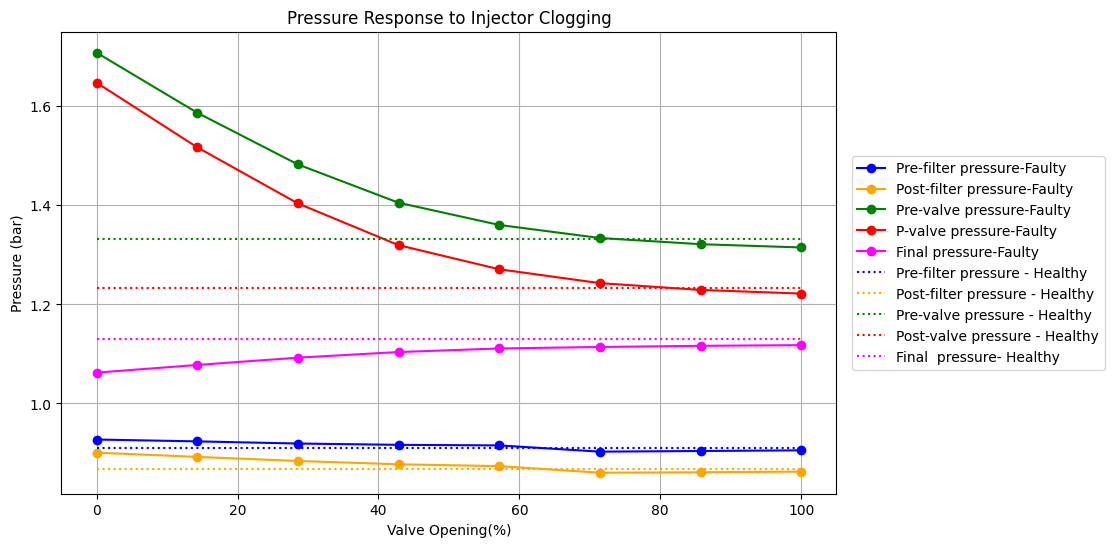

In [ ]:
# Pressure values for clogged filters
P1_nozzle = df_means_cn['PreFilter_Pressure']
P2_nozzle = df_means_cn['PostFilter_Pressure']
P3_nozzle = df_means_cn['PreValve_Pressure']
P4_nozzle = df_means_cn['PostValve_Pressure']
P5_nozzle = df_means_cn['Final_Pressure']

# Healthy pressures
# Use the length of P1_clogged (or any other clogged pressure) to determine degradation steps
degradation_steps = len(P1_nozzle)  # 8 in this case
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Adjust the length of healthy pressures to match degradation
P1_healthy = [combined_df_mean['PreFilter_Pressure']] * degradation_steps
P2_healthy = [combined_df_mean['PostFilter_Pressure']] * degradation_steps
P3_healthy = [combined_df_mean['PreValve_Pressure']] * degradation_steps
P4_healthy = [combined_df_mean['PostValve_Pressure']] * degradation_steps
P5_healthy = [combined_df_mean['Final_Pressure']] * degradation_steps

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(degradation, P1_nozzle, 'o-', label="Pre-filter pressure-Faulty", color='blue')
plt.plot(degradation, P2_nozzle, 'o-', label="Post-filter pressure-Faulty", color='orange')
plt.plot(degradation, P3_nozzle, 'o-', label="Pre-valve pressure-Faulty", color='green')
plt.plot(degradation, P4_nozzle, 'o-', label="P-valve pressure-Faulty", color='red')
plt.plot(degradation, P5_nozzle, 'o-', label="Final pressure-Faulty", color='magenta')

# Dotted lines for healthy reference
plt.plot(degradation, P1_healthy, 'blue', linestyle='dotted', label="Pre-filter pressure - Healthy")
plt.plot(degradation, P2_healthy, 'orange', linestyle='dotted', label="Post-filter pressure - Healthy")
plt.plot(degradation, P3_healthy, 'green', linestyle='dotted', label="Pre-valve pressure - Healthy")
plt.plot(degradation, P4_healthy, 'red', linestyle='dotted', label="Post-valve pressure - Healthy")
plt.plot(degradation, P5_healthy, 'magenta', linestyle='dotted', label="Final  pressure- Healthy")

plt.xlabel("Valve Opening(%)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Response to Injector Clogging")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.grid(True)
plt.show()

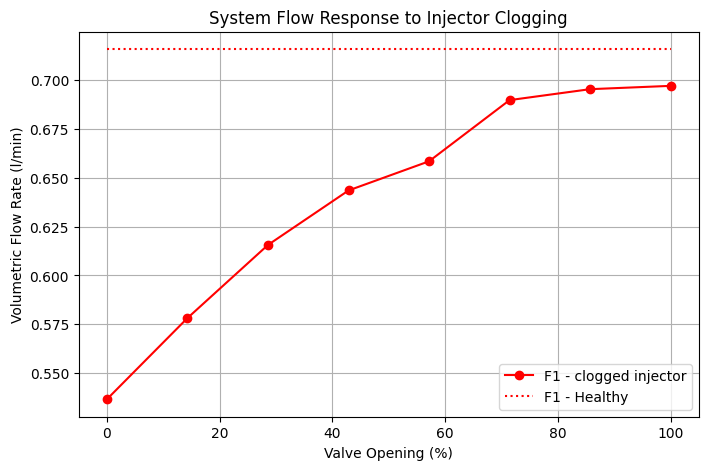

In [ ]:
# Example: Plot for PreFilter Pressure only

# Clogged filter pressure data
flow_nozzle = df_means_cn['volumetric_flow_rate']

# Healthy reference line (repeated to match degradation steps)
flow_healthy = [combined_df_mean['volumetric_flow_rate']] * len(flow_leak)

# Degradation axis (0% to 100%)
degradation_steps = len(flow_nozzle)
degradation = [(100 / (degradation_steps - 1)) * i for i in range(degradation_steps)]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(degradation, flow_nozzle, 'o-', color='red', label="F1 - clogged injector")
plt.plot(degradation, flow_healthy, linestyle='dotted', color='red', label="F1 - Healthy")

plt.xlabel("Valve Opening (%)")
plt.ylabel("Volumetric Flow Rate (l/min)")
plt.title("System Flow Response to Injector Clogging")
plt.legend()
plt.grid(True)
plt.show()


TASK 4

In [ ]:
# Directory containing LVM files
lvm_dir = "/content/drive/MyDrive/initial"
lvm_files = [f for f in os.listdir(lvm_dir) if f.endswith('.lvm')]

# Read all files
dataframes = []
for file in lvm_files:
    file_path = os.path.join(lvm_dir, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=22, header=None)  # Skip metadata lines
    dataframes.append(df)
    print(f"Read {file} with shape {df.shape}")

Read Test_2021_21-07-28_1457_PT_400rpm (1).lvm with shape (1200, 30)
Read Test_2021_21-07-28_1512_PT_450rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1517_PT_500rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1524_PT_550rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1531_PT_600rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1537_PT_650rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1542_PT_700rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1547_PT_750rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1553_PT_800rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1558_PT_850rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1603_PT_900rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1609_PT_950rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1620_PT_1000rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1625_PT_1050rpm.lvm with shape (1200, 30)
Read Test_2021_21-07-28_1630_PT_1100rpm.lvm with shape (1200, 30)
Read Test_2021_21-

In [ ]:
for i in range(len(dataframes)):
    dataframes[i] = dataframes[i].iloc[:, :-4]  # Select all rows and all but the last 4 columns
    print(f"Dataframe {i} shape after dropping columns: {dataframes[i].shape}")

Dataframe 0 shape after dropping columns: (1200, 26)
Dataframe 1 shape after dropping columns: (1200, 26)
Dataframe 2 shape after dropping columns: (1200, 26)
Dataframe 3 shape after dropping columns: (1200, 26)
Dataframe 4 shape after dropping columns: (1200, 26)
Dataframe 5 shape after dropping columns: (1200, 26)
Dataframe 6 shape after dropping columns: (1200, 26)
Dataframe 7 shape after dropping columns: (1200, 26)
Dataframe 8 shape after dropping columns: (1200, 26)
Dataframe 9 shape after dropping columns: (1200, 26)
Dataframe 10 shape after dropping columns: (1200, 26)
Dataframe 11 shape after dropping columns: (1200, 26)
Dataframe 12 shape after dropping columns: (1200, 26)
Dataframe 13 shape after dropping columns: (1200, 26)
Dataframe 14 shape after dropping columns: (1200, 26)
Dataframe 15 shape after dropping columns: (1200, 26)


In [ ]:
import string

for df in dataframes:
    num_cols = df.shape[1]  # Get the number of columns
    # Create a list of column names from 'A' to the required number
    new_cols = list(string.ascii_uppercase[:num_cols])
    df.columns = new_cols  # Rename the columns

In [ ]:
desired_columns = ['A', 'C', 'D', 'I', 'J', 'G'] + list(string.ascii_uppercase[21:])  # V to Z

for i in range(len(dataframes)):
    dataframes[i] = dataframes[i][desired_columns]
    print(f"Dataframe {i} shape after selecting columns: {dataframes[i].shape}")

Dataframe 0 shape after selecting columns: (1200, 11)
Dataframe 1 shape after selecting columns: (1200, 11)
Dataframe 2 shape after selecting columns: (1200, 11)
Dataframe 3 shape after selecting columns: (1200, 11)
Dataframe 4 shape after selecting columns: (1200, 11)
Dataframe 5 shape after selecting columns: (1200, 11)
Dataframe 6 shape after selecting columns: (1200, 11)
Dataframe 7 shape after selecting columns: (1200, 11)
Dataframe 8 shape after selecting columns: (1200, 11)
Dataframe 9 shape after selecting columns: (1200, 11)
Dataframe 10 shape after selecting columns: (1200, 11)
Dataframe 11 shape after selecting columns: (1200, 11)
Dataframe 12 shape after selecting columns: (1200, 11)
Dataframe 13 shape after selecting columns: (1200, 11)
Dataframe 14 shape after selecting columns: (1200, 11)
Dataframe 15 shape after selecting columns: (1200, 11)


In [ ]:
Initial_400rpm=dataframes[0]
Initial_450rpm=dataframes[1]
Initial_500rpm=dataframes[2]
Initial_550rpm=dataframes[3]
Initial_600rpm=dataframes[4]
Initial_650rpm=dataframes[5]
Initial_700rpm=dataframes[6]
Initial_750rpm=dataframes[7]
Initial_800rpm=dataframes[8]
Initial_850rpm=dataframes[9]
Initial_900rpm=dataframes[10]
Initial_950rpm=dataframes[11]
Initial_1000rpm=dataframes[12]
Initial_1050rpm=dataframes[13]
Initial_1100rpm=dataframes[14]
Initial_1140rpm=dataframes[15]

In [ ]:
new_names4 = ['Time', 'P2(bar)', 'P3(bar)', 'RPM', 'DP_Pump', 'F1(L/min)','DPV1_CMD','DPV2_CMD','DPV3_CMD','DPV4_CMD','DPV5_CMD']

In [ ]:
dataframes = [Initial_400rpm, Initial_450rpm, Initial_500rpm, Initial_550rpm, Initial_600rpm, Initial_650rpm, Initial_700rpm, Initial_750rpm, Initial_800rpm, Initial_850rpm, Initial_900rpm, Initial_950rpm, Initial_1000rpm, Initial_1050rpm, Initial_1100rpm, Initial_1140rpm]
for df in dataframes:
    df.columns = new_names4  # Assign the new column names

In [ ]:
Initial_650rpm

,Time,P2(bar),P3(bar),RPM,DP_Pump,F1(L/min),DPV1_CMD,DPV2_CMD,DPV3_CMD,DPV4_CMD,DPV5_CMD
0,0.0,0.816,1.829,650.0,1.010,1.1064,20000.0,4000.0,20000.0,20000.0,4000.0
1,0.0,0.815,1.807,650.0,1.013,1.1076,20000.0,4000.0,20000.0,20000.0,4000.0
2,0.0,0.819,1.795,650.0,0.992,1.1084,20000.0,4000.0,20000.0,20000.0,4000.0
3,0.0,0.821,1.794,650.0,0.976,1.1076,20000.0,4000.0,20000.0,20000.0,4000.0
4,0.0,0.824,1.790,650.0,0.973,1.1064,20000.0,4000.0,20000.0,20000.0,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
1195,0.0,0.996,4.549,650.0,3.523,0.3736,20000.0,4000.0,5584.0,5584.0,4000.0
1196,0.0,0.996,4.562,650.0,3.553,0.3744,20000.0,4000.0,5584.0,5584.0,4000.0
1197,0.0,0.997,4.567,650.0,3.566,0.3716,20000.0,4000.0,5584.0,5584.0,4000.0
1198,0.0,0.997,4.584,650.0,3.570,0.3720,20000.0,4000.0,5584.0,5584.0,4000.0


FINAL PUMP TEST

In [ ]:
# Directory containing LVM files
lvm_dir = "/content/drive/MyDrive/final"
lvm_files = [f for f in os.listdir(lvm_dir) if f.endswith('.lvm')]

# Read all files
dataframes1 = []
for file in lvm_files:
    file_path = os.path.join(lvm_dir, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=22, header=None)  # Skip metadata lines
    dataframes1.append(df)
    print(f"Read {file} with shape {df.shape}")

Read PT_700rpm_25_ Data_23-02-02_1007.lvm with shape (860, 30)
Read PT_750rpm_35_ Data_23-02-02_1018.lvm with shape (1047, 30)
Read PT_800rpm_35_ Data_23-02-02_1028.lvm with shape (718, 30)
Read PT_850rpm_35_ Data_23-02-02_1037.lvm with shape (741, 30)
Read PT_900rpm_35_ Data_23-02-02_1047.lvm with shape (820, 30)
Read PT_950rpm_35_ Data_23-02-02_1056.lvm with shape (740, 30)


In [ ]:
for i in range(len(dataframes1)):
    dataframes1[i] = dataframes1[i].iloc[:, :-4]  # Select all rows and all but the last 4 columns
    print(f"Dataframe {i} shape after dropping columns: {dataframes1[i].shape}")

Dataframe 0 shape after dropping columns: (860, 26)
Dataframe 1 shape after dropping columns: (1047, 26)
Dataframe 2 shape after dropping columns: (718, 26)
Dataframe 3 shape after dropping columns: (741, 26)
Dataframe 4 shape after dropping columns: (820, 26)
Dataframe 5 shape after dropping columns: (740, 26)


In [ ]:
import string

for df in dataframes1:
    num_cols = df.shape[1]  # Get the number of columns
    # Create a list of column names from 'A' to the required number
    new_cols = list(string.ascii_uppercase[:num_cols])
    df.columns = new_cols  # Rename the columns

In [ ]:
desired_columns = ['A', 'C', 'D', 'I', 'J', 'G'] + list(string.ascii_uppercase[21:])  # V to Z

for i in range(len(dataframes1)):
    dataframes1[i] = dataframes1[i][desired_columns]
    print(f"Dataframe1 {i} shape after selecting columns: {dataframes1[i].shape}")

Dataframe1 0 shape after selecting columns: (860, 11)
Dataframe1 1 shape after selecting columns: (1047, 11)
Dataframe1 2 shape after selecting columns: (718, 11)
Dataframe1 3 shape after selecting columns: (741, 11)
Dataframe1 4 shape after selecting columns: (820, 11)
Dataframe1 5 shape after selecting columns: (740, 11)


In [ ]:
desired_columns = ['A', 'C', 'D', 'I', 'J', 'G'] + list(string.ascii_uppercase[21:])  # V to Z

for i in range(len(dataframes1)):
    dataframes1[i] = dataframes1[i][desired_columns]
    print(f"Dataframe1 {i} shape after selecting columns: {dataframes1[i].shape}")

Dataframe1 0 shape after selecting columns: (860, 11)
Dataframe1 1 shape after selecting columns: (1047, 11)
Dataframe1 2 shape after selecting columns: (718, 11)
Dataframe1 3 shape after selecting columns: (741, 11)
Dataframe1 4 shape after selecting columns: (820, 11)
Dataframe1 5 shape after selecting columns: (740, 11)


In [ ]:
pt_700=dataframes1[0]
pt_750=dataframes1[1]
pt_800=dataframes1[2]
pt_850=dataframes1[3]
pt_900=dataframes1[4]
pt_950=dataframes1[5]

In [ ]:
dataframes = [pt_700, pt_750, pt_800, pt_850, pt_900, pt_950]
for df in dataframes:
    df.columns = new_names4  # Assign the new column names

In [ ]:
pt_700

,Time,P2(bar),P3(bar),RPM,DP_Pump,F1(L/min),DPV1_CMD,DPV2_CMD,DPV3_CMD,DPV4_CMD,DPV5_CMD
0,0.0,0.783,2.005,700.0,1.181,1.2276,20000.0,4000.0,20000.0,20000.0,4000.0
1,0.0,0.787,1.999,700.0,1.222,1.2316,20000.0,4000.0,20000.0,20000.0,4000.0
2,0.0,0.783,1.954,700.0,1.212,1.2300,20000.0,4000.0,20000.0,20000.0,4000.0
3,0.0,0.778,1.923,700.0,1.171,1.2296,20000.0,4000.0,20000.0,20000.0,4000.0
4,0.0,0.776,1.925,700.0,1.145,1.2272,20000.0,4000.0,20000.0,20000.0,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
855,0.0,0.910,3.962,700.0,2.924,0.8144,20000.0,4000.0,7984.0,7984.0,4000.0
856,0.0,0.921,4.050,700.0,3.052,0.8144,20000.0,4000.0,7984.0,7984.0,4000.0
857,0.0,0.914,3.976,700.0,3.129,0.8140,20000.0,4000.0,7984.0,7984.0,4000.0
858,0.0,0.907,3.835,700.0,3.062,0.8140,20000.0,4000.0,7984.0,7984.0,4000.0


In [ ]:
# Assuming c1, c2, ..., c16 are your DataFrames
for df in [Initial_400rpm, Initial_450rpm, Initial_500rpm, Initial_550rpm, Initial_600rpm, Initial_650rpm, Initial_700rpm, Initial_750rpm, Initial_800rpm, Initial_850rpm, Initial_900rpm, Initial_950rpm, Initial_1000rpm, Initial_1050rpm, Initial_1100rpm, Initial_1140rpm]:
    df['Pump_Pressure'] = df['P3(bar)'] - df['P2(bar)']

In [ ]:
dataframes = [Initial_400rpm, Initial_450rpm, Initial_500rpm, Initial_550rpm, Initial_600rpm, Initial_650rpm, Initial_700rpm, Initial_750rpm, Initial_800rpm, Initial_850rpm, Initial_900rpm, Initial_950rpm, Initial_1000rpm, Initial_1050rpm, Initial_1100rpm, Initial_1140rpm]

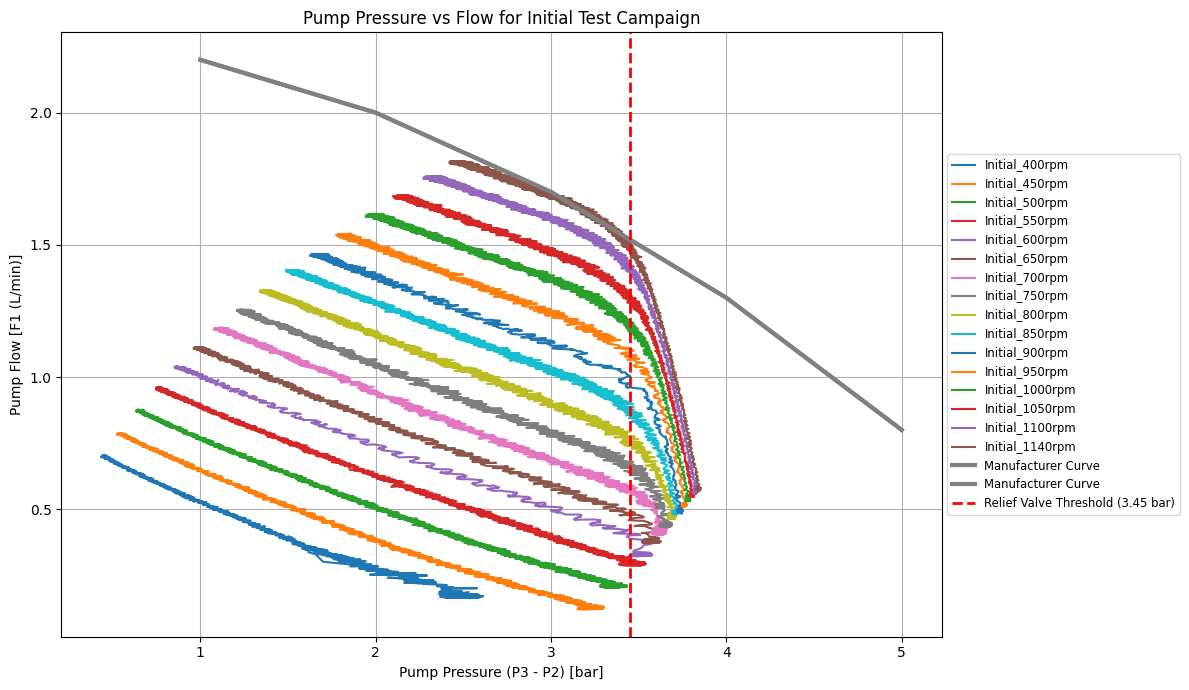

In [ ]:
import matplotlib.pyplot as plt

# Define manufacturer curve data
manufacturer_pressure = [1.0, 2.0, 3.0, 4.0, 5.0]
manufacturer_flow = [2.2, 2.0, 1.7, 1.3, 0.8]

# List of your DataFrames and corresponding names
dataframes = [
    Initial_400rpm, Initial_450rpm, Initial_500rpm, Initial_550rpm,
    Initial_600rpm, Initial_650rpm, Initial_700rpm, Initial_750rpm,
    Initial_800rpm, Initial_850rpm, Initial_900rpm, Initial_950rpm,
    Initial_1000rpm, Initial_1050rpm, Initial_1100rpm, Initial_1140rpm
]
labels = [
    "Initial_400rpm", "Initial_450rpm", "Initial_500rpm", "Initial_550rpm",
    "Initial_600rpm", "Initial_650rpm", "Initial_700rpm", "Initial_750rpm",
    "Initial_800rpm", "Initial_850rpm", "Initial_900rpm", "Initial_950rpm",
    "Initial_1000rpm", "Initial_1050rpm", "Initial_1100rpm", "Initial_1140rpm"
]

# Plot
plt.figure(figsize=(12, 7))
for df, label in zip(dataframes, labels):
    plt.plot(df["Pump_Pressure"], df["F1(L/min)"], label=label)

# Add manufacturer curve
plt.plot(manufacturer_pressure, manufacturer_flow, color='gray', linewidth=3, label='Manufacturer Curve')

# Plot styling
plt.xlabel("Pump Pressure (P3 - P2) [bar]")
plt.ylabel("Pump Flow [F1 (L/min)]")
plt.title("Pump Pressure vs Flow for Initial Test Campaign")
plt.grid(True)
# Add manufacturer curve
plt.plot(manufacturer_pressure, manufacturer_flow, color='gray', linewidth=3, label='Manufacturer Curve')

# Add relief valve threshold line
threshold = 3.45  # or 3.4 if you prefer
plt.axvline(x=threshold, color='red', linewidth=2, linestyle='--', label= "Relief Valve Threshold (3.45 bar)")

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.tight_layout()
plt.show()


In [ ]:
# Calculate pump pressure for each dataframe
pt_700['Pump_Pressure'] = pt_700['P3(bar)'] - pt_700['P2(bar)']
pt_750['Pump_Pressure'] = pt_750['P3(bar)'] - pt_750['P2(bar)']
pt_800['Pump_Pressure'] = pt_800['P3(bar)'] - pt_800['P2(bar)']
pt_850['Pump_Pressure'] = pt_850['P3(bar)'] - pt_850['P2(bar)']
pt_900['Pump_Pressure'] = pt_900['P3(bar)'] - pt_900['P2(bar)']
pt_950['Pump_Pressure'] = pt_950['P3(bar)'] - pt_950['P2(bar)']
Initial_700rpm['Pump_Pressure'] = Initial_700rpm['P3(bar)'] - Initial_700rpm['P2(bar)']
Initial_750rpm['Pump_Pressure'] = Initial_750rpm['P3(bar)'] - Initial_750rpm['P2(bar)']
Initial_800rpm['Pump_Pressure'] = Initial_800rpm['P3(bar)'] - Initial_800rpm['P2(bar)']
Initial_850rpm['Pump_Pressure'] = Initial_850rpm['P3(bar)'] - Initial_850rpm['P2(bar)']
Initial_900rpm['Pump_Pressure'] = Initial_900rpm['P3(bar)'] - Initial_900rpm['P2(bar)']
Initial_950rpm['Pump_Pressure'] = Initial_950rpm['P3(bar)'] - Initial_950rpm['P2(bar)']

<ipython-input-212-83da6a33f072>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', 12)


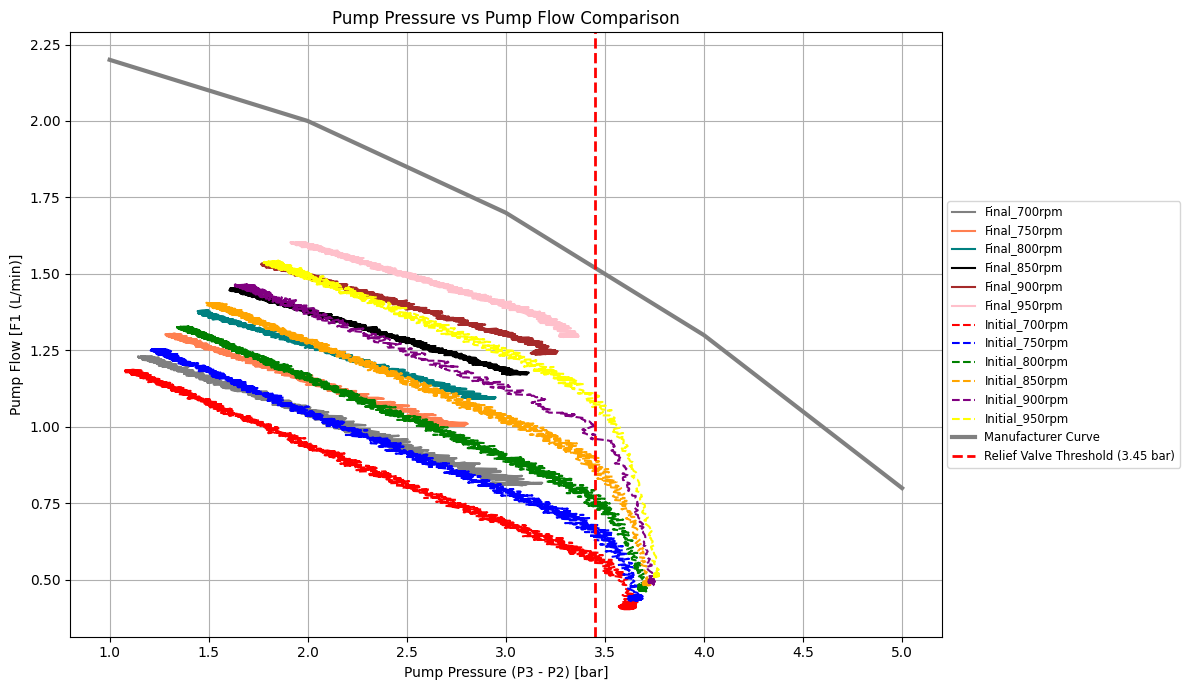

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Manufacturer reference curve
manufacturer_pressure = [1.0, 2.0, 3.0, 4.0, 5.0]
manufacturer_flow = [2.2, 2.0, 1.7, 1.3, 0.8]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# Use consistent colormap
colors = cm.get_cmap('tab20', 12)

# Final test campaign curves
ax.plot(pt_700['Pump_Pressure'], pt_700['F1(L/min)'], label='Final_700rpm', color="grey")
ax.plot(pt_750['Pump_Pressure'], pt_750['F1(L/min)'], label='Final_750rpm', color="coral")
ax.plot(pt_800['Pump_Pressure'], pt_800['F1(L/min)'], label='Final_800rpm', color="teal")
ax.plot(pt_850['Pump_Pressure'], pt_850['F1(L/min)'], label='Final_850rpm', color="black")
ax.plot(pt_900['Pump_Pressure'], pt_900['F1(L/min)'], label='Final_900rpm', color="brown")
ax.plot(pt_950['Pump_Pressure'], pt_950['F1(L/min)'], label='Final_950rpm', color="pink")

# Initial test campaign curves
ax.plot(Initial_700rpm['Pump_Pressure'], Initial_700rpm['F1(L/min)'], label='Initial_700rpm', linestyle='--', color="red")
ax.plot(Initial_750rpm['Pump_Pressure'], Initial_750rpm['F1(L/min)'], label='Initial_750rpm', linestyle='--', color="blue")
ax.plot(Initial_800rpm['Pump_Pressure'], Initial_800rpm['F1(L/min)'], label='Initial_800rpm', linestyle='--', color="green")
ax.plot(Initial_850rpm['Pump_Pressure'], Initial_850rpm['F1(L/min)'], label='Initial_850rpm', linestyle='--', color="orange")
ax.plot(Initial_900rpm['Pump_Pressure'], Initial_900rpm['F1(L/min)'], label='Initial_900rpm', linestyle='--', color="purple")
ax.plot(Initial_950rpm['Pump_Pressure'], Initial_950rpm['F1(L/min)'], label='Initial_950rpm', linestyle='--', color="yellow")

# Manufacturer reference curve
ax.plot(manufacturer_pressure, manufacturer_flow, color='gray', linewidth=3, label='Manufacturer Curve')

# Add OEM SRV Threshold line
srv_pressure = 3.45
ax.axvline(x=srv_pressure, color='red', linestyle='--', linewidth=2, label='Relief Valve Threshold (3.45 bar)')

# Labels and title
ax.set_xlabel('Pump Pressure (P3 - P2) [bar]')
ax.set_ylabel('Pump Flow [F1 (L/min)]')
ax.set_title('Pump Pressure vs Pump Flow Comparison')
ax.grid(True)

# Legend outside
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


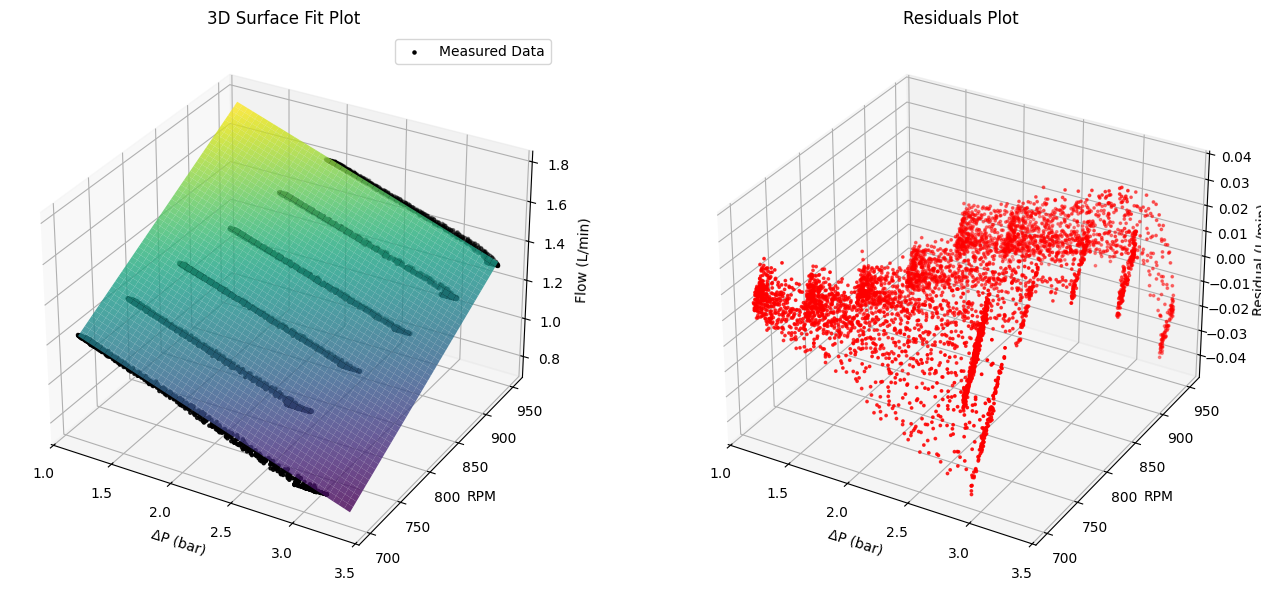

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.linear_model import LinearRegression

# Combine all final PT DataFrames into one
final_dfs = [pt_700, pt_750, pt_800, pt_850, pt_900, pt_950]
combined_df = pd.concat(final_dfs, ignore_index=True)

# Calculate Pump Pressure (P3 - P2)
combined_df['Pump_Pressure'] = combined_df['P3(bar)'] - combined_df['P2(bar)']

# Extract variables
X = combined_df[['Pump_Pressure', 'RPM']]
y = combined_df['F1(L/min)']

# Fit a linear regression model (you can replace with other regressors)
model = LinearRegression()
model.fit(X, y)

# Predict using model
combined_df['F1_pred'] = model.predict(X)
combined_df['Residual'] = combined_df['F1(L/min)'] - combined_df['F1_pred']

# Create meshgrid for 3D surface
pp_range = np.linspace(X['Pump_Pressure'].min(), X['Pump_Pressure'].max(), 50)
rpm_range = np.linspace(X['RPM'].min(), X['RPM'].max(), 50)
pp_mesh, rpm_mesh = np.meshgrid(pp_range, rpm_range)
X_grid = np.c_[pp_mesh.ravel(), rpm_mesh.ravel()]
y_grid = model.predict(X_grid).reshape(pp_mesh.shape)

# ---- PLOT ----
fig = plt.figure(figsize=(14, 6))

# 3D Surface Fit Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(pp_mesh, rpm_mesh, y_grid, cmap=cm.viridis, alpha=0.8)
ax1.scatter(combined_df['Pump_Pressure'], combined_df['RPM'], combined_df['F1(L/min)'],
            color='k', s=5, label='Measured Data')
ax1.set_xlabel('ΔP (bar)')
ax1.set_ylabel('RPM')
ax1.set_zlabel('Flow (L/min)')
ax1.set_title('3D Surface Fit Plot')
ax1.legend()

# Residuals Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
residuals = combined_df['Residual']
ax2.scatter(combined_df['Pump_Pressure'], combined_df['RPM'], residuals,
            c='red', s=3)
ax2.set_xlabel('ΔP (bar)')
ax2.set_ylabel('RPM')
ax2.set_zlabel('Residual (L/min)')
ax2.set_title('Residuals Plot')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

# Step 1: Create the features and target
X = combined_df[['Pump_Pressure', 'RPM']]  # ΔP and RPM
y = combined_df['F1(L/min)']  # Flow

# Step 2: Scale the features (ΔP and RPM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Fit the model
model = LinearRegression()
model.fit(X_scaled, y)

# Step 4: Display coefficients
coefficients = model.coef_
intercept = model.intercept_

print("Model equation:")
print(f"Flow = {coefficients[0]:.4f} * scaled_ΔP + {coefficients[1]:.4f} * scaled_RPM + {intercept:.4f}")


Model equation:
Flow = -0.1228 * scaled_ΔP + 0.1898 * scaled_RPM + 1.2734


In [ ]:
mu_dp = combined_df['RPM'].mean()
std_dp = combined_df['RPM'].std()

mu_rpm = combined_df['RPM'].mean()
std_rpm = combined_df['RPM'].std()

# Reconstruct coefficients
a = -0.1228
b = 0.1898
c = 1.2734

coef_dp = a / std_dp
coef_rpm = b / std_rpm
intercept = c - (a * mu_dp / std_dp) - (b * mu_rpm / std_rpm)

print(f"Flow = {coef_dp:.4f} * ΔP + {coef_rpm:.4f} * RPM + {intercept:.4f}")


Flow = -0.0014 * ΔP + 0.0022 * RPM + 0.6338


In [ ]:
# Apply the same scaling
X_scaled = scaler.transform(X)  # Use X before scaling
y_pred = model.predict(X_scaled)

# Calculate metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f} L/min")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} L/min")


R² Score: 0.9966
MAE: 0.0084 L/min
MSE: 0.0001
RMSE: 0.0109 L/min


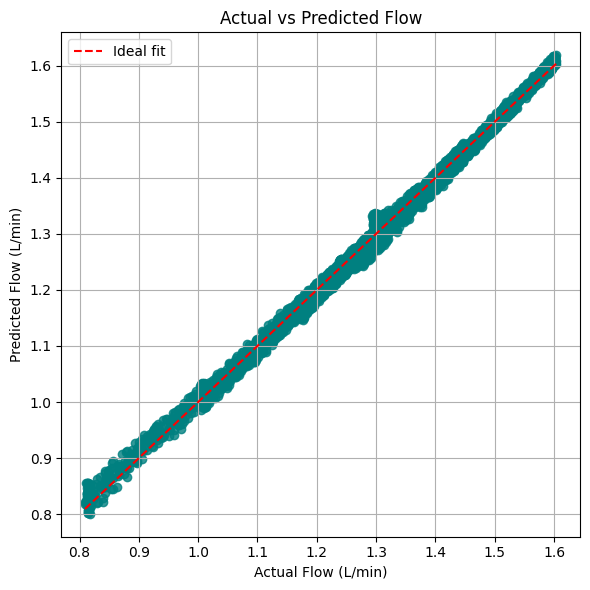

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.8, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal fit')
plt.xlabel("Actual Flow (L/min)")
plt.ylabel("Predicted Flow (L/min)")
plt.title("Actual vs Predicted Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion
This notebook constructed a practical digital shadow of the fuel system by (i) defining a stable healthy baseline for pressures and flow, (ii) examining how signals deviate under progressively faulted conditions, and (iii) modelling pump behaviour with a simple, interpretable equation/surface. The analysis highlights which variables respond earliest and most strongly to degradation, and it quantifies severity trends relative to healthy operation.

Overall, the results provide a clear diagnostic picture of system behaviour and a lightweight predictive model that’s useful for monitoring and what-if checks. Natural next steps toward a full digital twin include streaming data ingestion, automated detection (ML-based anomaly/fault scoring), and closed-loop decision support for real-time alerting and control.
